<a href="https://colab.research.google.com/github/glender222/ACP-COMBUSTIBLE/blob/main/examenParte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
ruta = "/content/datacombustible_lpc5deqndn.xlsx"
df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (19709, 11)


,fecha_emision,fecha_corte,id,producto,fe_inventario,cantidad_mb,fe_proceso,cantidad_mb_lim,vlmen_fndo_ttal,ANON_CO_OSINERG,ANON_PTA_ABASTECIMIENTO
0,20250701,20250701,1,G Premium,2025-01-12 00:00:00,35.98500,2025-01-19 12:10:02,35.98500,0.03300,3dcd3239e2,83ae64708f
1,20250701,20250701,2,G Premium,2025-01-09 00:00:00,0.00000,2025-01-16 12:10:02,0.00000,0.00000,2127ae39c1,fdb7133ee2
2,20250701,20250701,3,G Premium,2025-01-22 00:00:00,0.32607,2025-01-29 12:10:02,0.32607,0.00029,6ef1e6909e,9fc7ed4647
3,20250701,20250701,4,G Premium,2025-02-02 00:00:00,16.21480,2025-02-09 12:10:02,16.21480,2.61570,98feeeb363,335ac645f3
4,20250701,20250701,5,G Premium,2025-01-05 00:00:00,0.00000,2025-01-12 12:10:01,0.00000,0.00000,13c3a19c48,0af6a53b9b


In [ ]:
print(df.columns.tolist())
print("\nTipos de dato:")
print(df.dtypes)

print("\nNulos por columna:")
print(df.isna().sum())

['fecha_emision', 'fecha_corte', 'id', 'producto', 'fe_inventario', 'cantidad_mb', 'fe_proceso', 'cantidad_mb_lim', 'vlmen_fndo_ttal', 'ANON_CO_OSINERG', 'ANON_PTA_ABASTECIMIENTO']

Tipos de dato:
fecha_emision                int64
fecha_corte                  int64
id                           int64
producto                    object
fe_inventario               object
cantidad_mb                float64
fe_proceso                  object
cantidad_mb_lim            float64
vlmen_fndo_ttal            float64
ANON_CO_OSINERG             object
ANON_PTA_ABASTECIMIENTO     object
dtype: object

Nulos por columna:
fecha_emision              0
fecha_corte                0
id                         0
producto                   0
fe_inventario              0
cantidad_mb                0
fe_proceso                 0
cantidad_mb_lim            0
vlmen_fndo_ttal            0
ANON_CO_OSINERG            0
ANON_PTA_ABASTECIMIENTO    0
dtype: int64


In [ ]:
df["fecha_emision"] = pd.to_datetime(df["fecha_emision"].astype(str), format="%Y%m%d", errors="coerce")
df["fecha_corte"] = pd.to_datetime(df["fecha_corte"].astype(str), format="%Y%m%d", errors="coerce")
df["fe_inventario"] = pd.to_datetime(df["fe_inventario"], errors="coerce")
df["fe_proceso"] = pd.to_datetime(df["fe_proceso"], errors="coerce")

In [ ]:
df["dias_inv_proceso"] = (df["fe_proceso"].dt.floor("D") - df["fe_inventario"]).dt.days

In [ ]:
variables_pca = ["cantidad_mb", "vlmen_fndo_ttal", "dias_inv_proceso"]

X = df[variables_pca].copy()
X = X.dropna()

print("Dimensiones de X:", X.shape)
X.head()

Dimensiones de X: (19709, 3)


,cantidad_mb,vlmen_fndo_ttal,dias_inv_proceso
0,35.98500,0.03300,7
1,0.00000,0.00000,7
2,0.32607,0.00029,7
3,16.21480,2.61570,7
4,0.00000,0.00000,7


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.05032149 -0.28800614  0.18046048]
 [-0.42334378 -0.29081375  0.18046048]
 [-0.41996373 -0.29078908  0.18046048]
 [-0.25526036 -0.06827197  0.18046048]
 [-0.42334378 -0.29081375  0.18046048]]


In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Shape transformado:", X_pca.shape)

Shape transformado: (19709, 3)


In [ ]:
var_exp = pca.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, v in enumerate(var_exp, start=1):
    print(f"PC{i}: {v:.4f}")

print("\nVarianza acumulada:")
for i, v in enumerate(var_exp_acum, start=1):
    print(f"PC{i}: {v:.4f}")

Varianza explicada por componente:
PC1: 0.5427
PC2: 0.3334
PC3: 0.1240

Varianza acumulada:
PC1: 0.5427
PC2: 0.8760
PC3: 1.0000


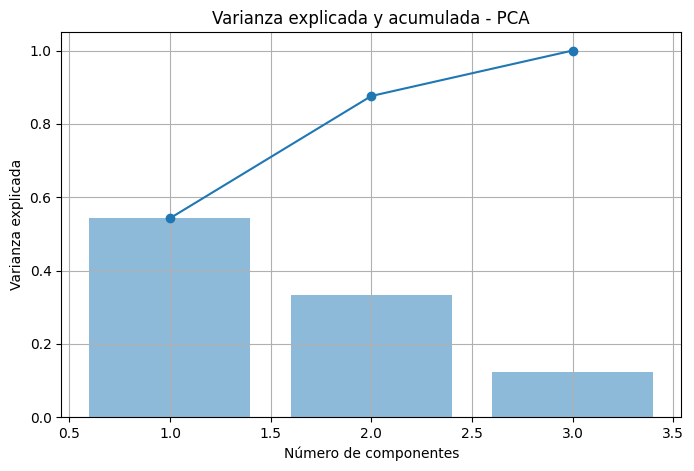

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_exp)+1), var_exp_acum, marker='o')
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.5)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada y acumulada - PCA")
plt.grid(True)
plt.show()

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=X.columns)

for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].sort_values(ascending=False))


PC1
cantidad_mb         0.707121
vlmen_fndo_ttal     0.707008
dias_inv_proceso    0.010933
Name: PC1, dtype: float64

PC2
dias_inv_proceso    0.999835
cantidad_mb         0.002547
vlmen_fndo_ttal    -0.018008
Name: PC2, dtype: float64

PC3
cantidad_mb         0.707088
dias_inv_proceso   -0.014534
vlmen_fndo_ttal    -0.706976
Name: PC3, dtype: float64


In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"], index=X.index)
df_pca.head()

,PC1,PC2
0,-0.237233,0.185489
1,-0.502990,0.184590
2,-0.500582,0.184598
3,-0.226796,0.181010
4,-0.502990,0.184590


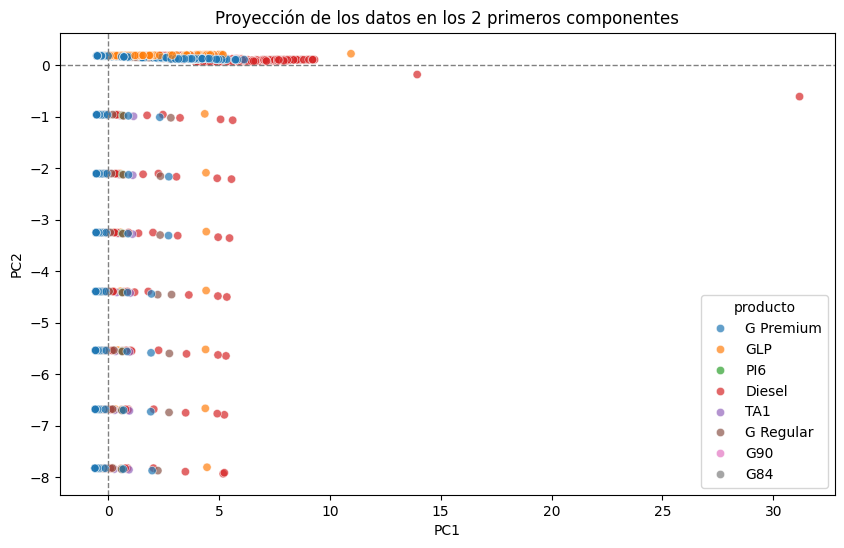

In [ ]:
df_plot = df.loc[X.index].copy()
df_plot["PC1"] = df_pca["PC1"]
df_plot["PC2"] = df_pca["PC2"]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="producto", alpha=0.7)
plt.title("Proyección de los datos en los 2 primeros componentes")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

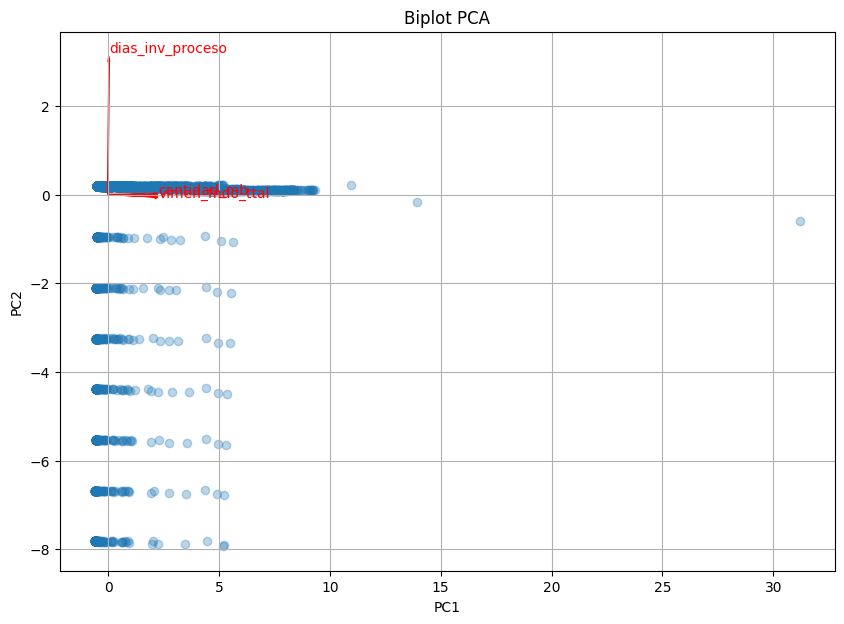

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.3)

for i, var in enumerate(variables_pca):
    plt.arrow(
        0, 0,
        loadings.loc[var, "PC1"] * 3,
        loadings.loc[var, "PC2"] * 3,
        head_width=0.08,
        color='red'
    )
    plt.text(
        loadings.loc[var, "PC1"] * 3.2,
        loadings.loc[var, "PC2"] * 3.2,
        var,
        color='red'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA")
plt.grid(True)
plt.show()

In [ ]:
resultado = df.loc[X.index].copy()
resultado["PC1"] = df_pca["PC1"]
resultado["PC2"] = df_pca["PC2"]

resultado.to_excel("/content/resultado_pca.xlsx", index=False)
print("Archivo guardado: /content/resultado_pca.xlsx")

Archivo guardado: /content/resultado_pca.xlsx


Data docentes analisis EDA : DIAGRMAS DE CAJAS : ANALISIS DESCRIPTIVO


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")

# Ruta del archivo (ajusta el nombre si cambia)
archivo = '/content/datadocentes2_hnupaddpq7.xlsx'

# Cargar hoja principal
df = pd.read_excel(archivo, sheet_name='docente_2025_I')

# Ver primeras filas
df.head()

,CODIGO_INEI,ENTIDAD,LICENCIA,TIPO_GESTION,TIPO_ENTIDAD,TIPO_CONSTITUCION,PERIODO_ACADEMICO,GRUPO_INVESTIGADOR,NIVEL_INVESTIGADOR,FECHA_CALIFICACION_INICIO,...,ANIO_NACIMIENTO,EDAD,SEXO,NACIONALIDAD,DEPARTAMENTO_NACIMIENTO,CONDICION_LABORAL,CATEGORIA_DOCENTE,REGIMEN_DEDICACION,FECHA_INICIO_PERIODO,FECHA_FIN_PERIODO
0,160000007.0,Universidad Nacional Agraria La Molina,Licenciada,Público,Universidad,Pública,2025-01-01,NaN,NaN,NaT,...,1959.0,66.0,Masculino,PERUANA,Lima,Ordinario,Ordinario Principal,Dedicación Exclusiva,2025-03-01,2025-07-18
1,160000007.0,Universidad Nacional Agraria La Molina,Licenciada,Público,Universidad,Pública,2025-01-01,NaN,NaN,NaT,...,1950.0,74.0,Masculino,PERUANA,Áncash,Ordinario,Ordinario Principal,Dedicación Exclusiva,2025-03-01,2025-07-18
2,160000007.0,Universidad Nacional Agraria La Molina,Licenciada,Público,Universidad,Pública,2025-01-01,Maria Rostworowski,III,2019-10-01,...,1954.0,71.0,Masculino,PERUANA,Lima,Ordinario,Ordinario Principal,Dedicación Exclusiva,2025-03-01,2025-07-18
3,160000007.0,Universidad Nacional Agraria La Molina,Licenciada,Público,Universidad,Pública,2025-01-01,Maria Rostworowski,III,2020-07-02,...,1979.0,46.0,Masculino,PERUANA,Lima,Ordinario,Ordinario Asociado,Dedicación Exclusiva,2025-03-07,2025-07-31
4,160000007.0,Universidad Nacional Agraria La Molina,Licenciada,Público,Universidad,Pública,2025-01-01,Maria Rostworowski,III,2020-07-02,...,1979.0,46.0,Masculino,PERUANA,Lima,Ordinario,Ordinario Asociado,Dedicación Exclusiva,2025-03-07,2025-07-31


In [2]:
# Dimensiones
print("Filas y columnas:", df.shape)

# Nombres de columnas
print("\nColumnas:")
print(df.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Información general
print("\nInformación general:")
df.info()

Filas y columnas: (54950, 29)

Columnas:
['CODIGO_INEI', 'ENTIDAD', 'LICENCIA', 'TIPO_GESTION', 'TIPO_ENTIDAD', 'TIPO_CONSTITUCION', 'PERIODO_ACADEMICO', 'GRUPO_INVESTIGADOR', 'NIVEL_INVESTIGADOR', 'FECHA_CALIFICACION_INICIO', 'FECHA_CALIFICACION_FIN', 'PERIODO_ESTANDAR', 'PERIODO_LECTIVO', 'NIVEL_ACADEMICO', 'GUID_PERSONA', 'TIPO_GRADO_TITULO', 'DENOMINACION_ENTIDAD', 'FECHA_EXPEDICION_DIPLOMA', 'PAIS_ENTIDAD', 'ANIO_NACIMIENTO', 'EDAD', 'SEXO', 'NACIONALIDAD', 'DEPARTAMENTO_NACIMIENTO', 'CONDICION_LABORAL', 'CATEGORIA_DOCENTE', 'REGIMEN_DEDICACION', 'FECHA_INICIO_PERIODO', 'FECHA_FIN_PERIODO']

Tipos de datos:
CODIGO_INEI                         float64
ENTIDAD                              object
LICENCIA                             object
TIPO_GESTION                         object
TIPO_ENTIDAD                         object
TIPO_CONSTITUCION                    object
PERIODO_ACADEMICO            datetime64[ns]
GRUPO_INVESTIGADOR                   object
NIVEL_INVESTIGADOR          

In [3]:
# Conteo de nulos
nulos = df.isnull().sum().sort_values(ascending=False)

# Porcentaje de nulos
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Tabla resumen
tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje_%': porcentaje_nulos
})

tabla_nulos[tabla_nulos['nulos'] > 0]

,nulos,porcentaje_%
NIVEL_INVESTIGADOR,53056,96.553230
FECHA_CALIFICACION_INICIO,53056,96.553230
FECHA_CALIFICACION_FIN,53056,96.553230
GRUPO_INVESTIGADOR,53056,96.553230
CODIGO_INEI,3164,5.757962
DEPARTAMENTO_NACIMIENTO,1327,2.414923
FECHA_EXPEDICION_DIPLOMA,944,1.717925
DENOMINACION_ENTIDAD,543,0.988171
PAIS_ENTIDAD,543,0.988171
TIPO_GRADO_TITULO,541,0.984531


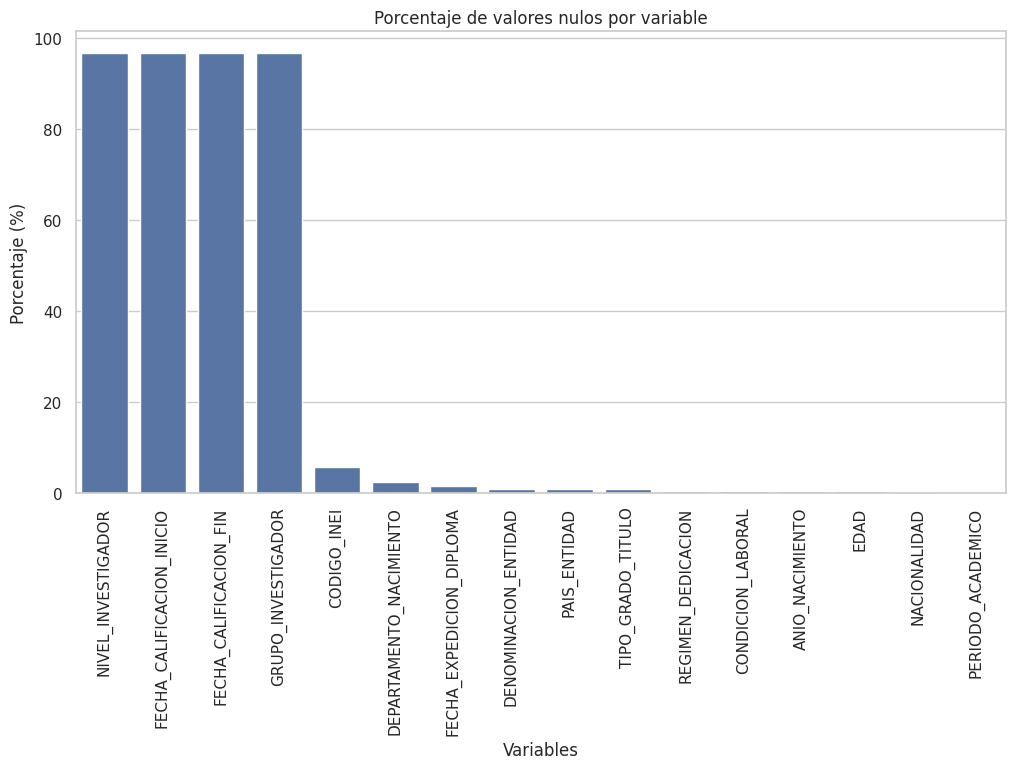

In [4]:
nulos_filtrados = tabla_nulos[tabla_nulos['nulos'] > 0].sort_values('porcentaje_%', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=nulos_filtrados.index, y=nulos_filtrados['porcentaje_%'])
plt.xticks(rotation=90)
plt.title('Porcentaje de valores nulos por variable')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Variables')
plt.show()

In [5]:
# Eliminar espacios en nombres de columnas
df.columns = df.columns.str.strip()

# Revisar duplicados exactos
print("Duplicados exactos:", df.duplicated().sum())

# Eliminar duplicados exactos si deseas
df = df.drop_duplicates()

print("Nuevo tamaño:", df.shape)

Duplicados exactos: 0
Nuevo tamaño: (54950, 29)


In [6]:
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()
fechas = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Variables numéricas:", numericas)
print("\nVariables categóricas:", categoricas)
print("\nVariables fecha:", fechas)

Variables numéricas: ['CODIGO_INEI', 'ANIO_NACIMIENTO', 'EDAD']

Variables categóricas: ['ENTIDAD', 'LICENCIA', 'TIPO_GESTION', 'TIPO_ENTIDAD', 'TIPO_CONSTITUCION', 'GRUPO_INVESTIGADOR', 'NIVEL_INVESTIGADOR', 'PERIODO_LECTIVO', 'NIVEL_ACADEMICO', 'GUID_PERSONA', 'TIPO_GRADO_TITULO', 'DENOMINACION_ENTIDAD', 'PAIS_ENTIDAD', 'SEXO', 'NACIONALIDAD', 'DEPARTAMENTO_NACIMIENTO', 'CONDICION_LABORAL', 'CATEGORIA_DOCENTE', 'REGIMEN_DEDICACION']

Variables fecha: ['PERIODO_ACADEMICO', 'FECHA_CALIFICACION_INICIO', 'FECHA_CALIFICACION_FIN', 'PERIODO_ESTANDAR', 'FECHA_EXPEDICION_DIPLOMA', 'FECHA_INICIO_PERIODO', 'FECHA_FIN_PERIODO']


In [7]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
CODIGO_INEI,51786.0,2.279817e+08,4.665513e+07,160000001.0,160000028.0,260000019.0,260000064.0,260000843.0
ANIO_NACIMIENTO,54694.0,1.974162e+03,1.214305e+01,1944.0,1965.0,1975.0,1984.0,2000.0
EDAD,54694.0,5.042520e+01,1.213862e+01,25.0,41.0,49.0,60.0,80.0


In [8]:
estadisticas = df[numericas].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
estadisticas

,count,mean,median,std,min,max
CODIGO_INEI,51786.0,2.279817e+08,260000019.0,4.665513e+07,160000001.0,260000843.0
ANIO_NACIMIENTO,54694.0,1.974162e+03,1975.0,1.214305e+01,1944.0,2000.0
EDAD,54694.0,5.042520e+01,49.0,1.213862e+01,25.0,80.0


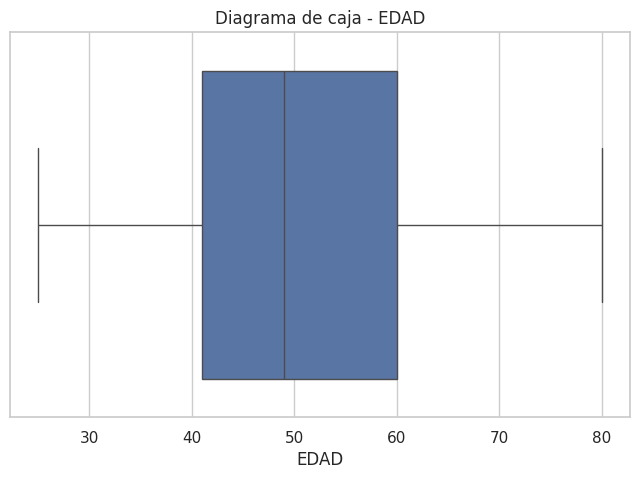

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['EDAD'])
plt.title('Diagrama de caja - EDAD')
plt.show()

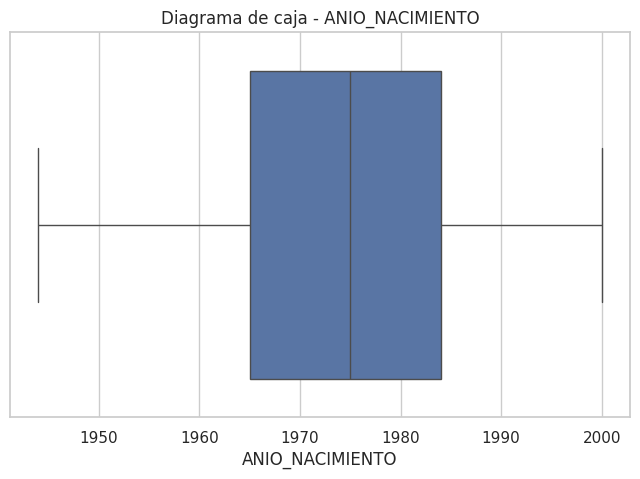

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ANIO_NACIMIENTO'])
plt.title('Diagrama de caja - ANIO_NACIMIENTO')
plt.show()

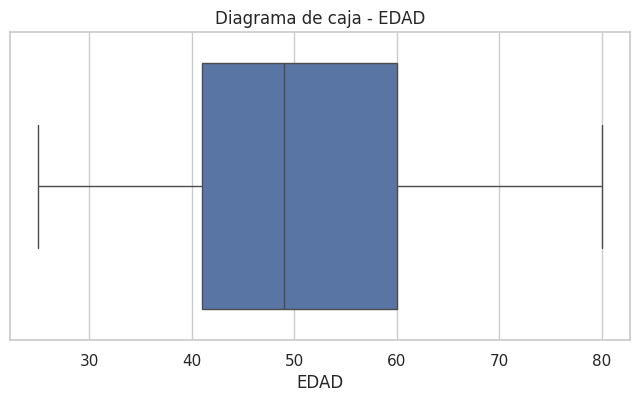

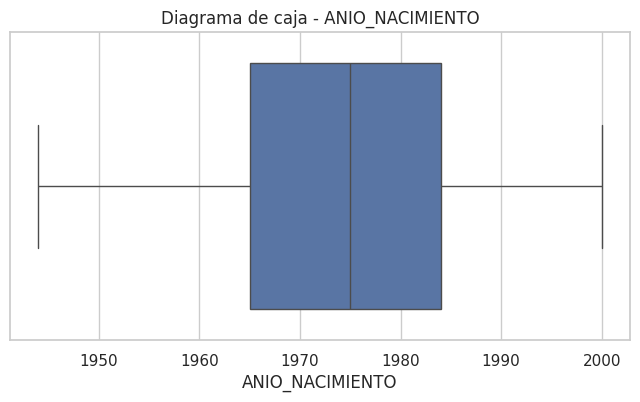

In [11]:
variables_boxplot = ['EDAD', 'ANIO_NACIMIENTO']

for col in variables_boxplot:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Diagrama de caja - {col}')
    plt.show()

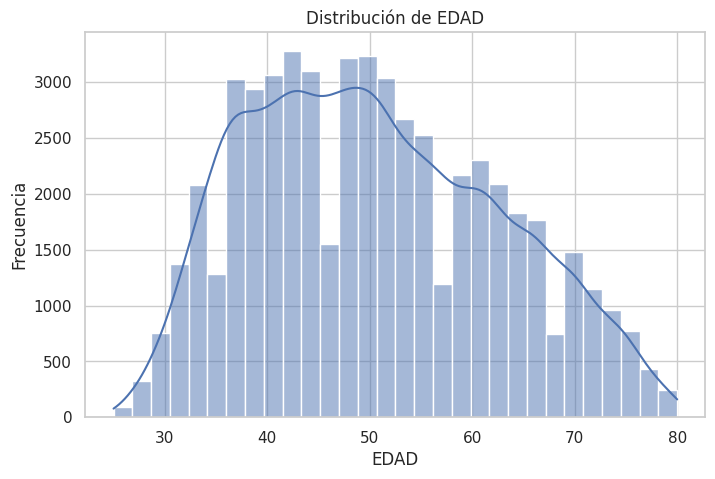

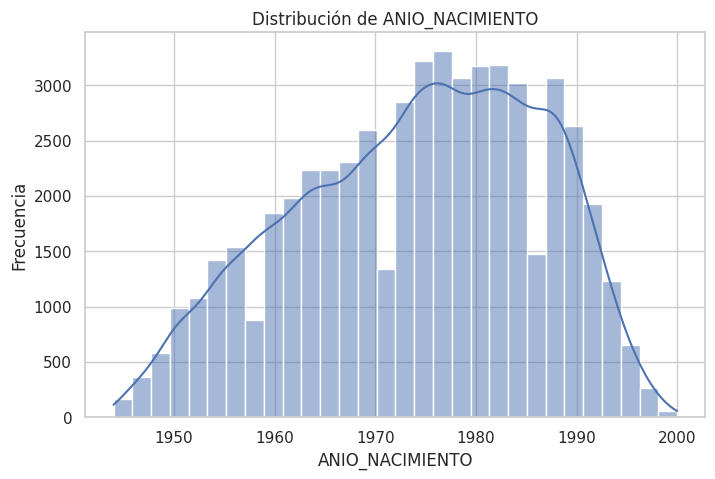

In [12]:
variables_hist = ['EDAD', 'ANIO_NACIMIENTO']

for col in variables_hist:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

In [13]:
def detectar_outliers_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    return {
        'columna': columna,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_outliers': outliers.shape[0]
    }

for col in ['EDAD', 'ANIO_NACIMIENTO']:
    print(detectar_outliers_iqr(df, col))
    print('-' * 50)

{'columna': 'EDAD', 'Q1': np.float64(41.0), 'Q3': np.float64(60.0), 'IQR': np.float64(19.0), 'limite_inferior': np.float64(12.5), 'limite_superior': np.float64(88.5), 'cantidad_outliers': 0}
--------------------------------------------------
{'columna': 'ANIO_NACIMIENTO', 'Q1': np.float64(1965.0), 'Q3': np.float64(1984.0), 'IQR': np.float64(19.0), 'limite_inferior': np.float64(1936.5), 'limite_superior': np.float64(2012.5), 'cantidad_outliers': 0}
--------------------------------------------------


In [14]:
for col in categoricas:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).head(10))


===== ENTIDAD =====
ENTIDAD
Universidad Tecnológica del Perú S.A.C.     7129
Universidad Nacional Mayor de San Marcos    3527
Pontificia Universidad Católica del Perú    3349
Universidad de San Martín de Porres         2143
Universidad Privada del Norte S.A.C.        2109
Universidad Científica del Sur S.A.C.       2075
Universidad Continental S.A.C.              2022
Universidad de Lima                         1525
Universidad Peruana Cayetano Heredia        1490
Universidad Nacional del Altiplano          1485
Name: count, dtype: int64

===== LICENCIA =====
LICENCIA
Licenciada           54489
Licencia Denegada      252
Ley de Creación        209
Name: count, dtype: int64

===== TIPO_GESTION =====
TIPO_GESTION
Privado    38227
Público    16723
Name: count, dtype: int64

===== TIPO_ENTIDAD =====
TIPO_ENTIDAD
Universidad            54645
Escuela Superior         159
Escuela de Posgrado       96
Instituto                 50
Name: count, dtype: int64

===== TIPO_CONSTITUCION =====
TIPO_C

In [15]:
for col in categoricas:
    print(f"\n===== {col} =====")
    print((df[col].value_counts(normalize=True, dropna=False) * 100).round(2).head(10))


===== ENTIDAD =====
ENTIDAD
Universidad Tecnológica del Perú S.A.C.     12.97
Universidad Nacional Mayor de San Marcos     6.42
Pontificia Universidad Católica del Perú     6.09
Universidad de San Martín de Porres          3.90
Universidad Privada del Norte S.A.C.         3.84
Universidad Científica del Sur S.A.C.        3.78
Universidad Continental S.A.C.               3.68
Universidad de Lima                          2.78
Universidad Peruana Cayetano Heredia         2.71
Universidad Nacional del Altiplano           2.70
Name: proportion, dtype: float64

===== LICENCIA =====
LICENCIA
Licenciada           99.16
Licencia Denegada     0.46
Ley de Creación       0.38
Name: proportion, dtype: float64

===== TIPO_GESTION =====
TIPO_GESTION
Privado    69.57
Público    30.43
Name: proportion, dtype: float64

===== TIPO_ENTIDAD =====
TIPO_ENTIDAD
Universidad            99.44
Escuela Superior        0.29
Escuela de Posgrado     0.17
Instituto               0.09
Name: proportion, dtype: float64

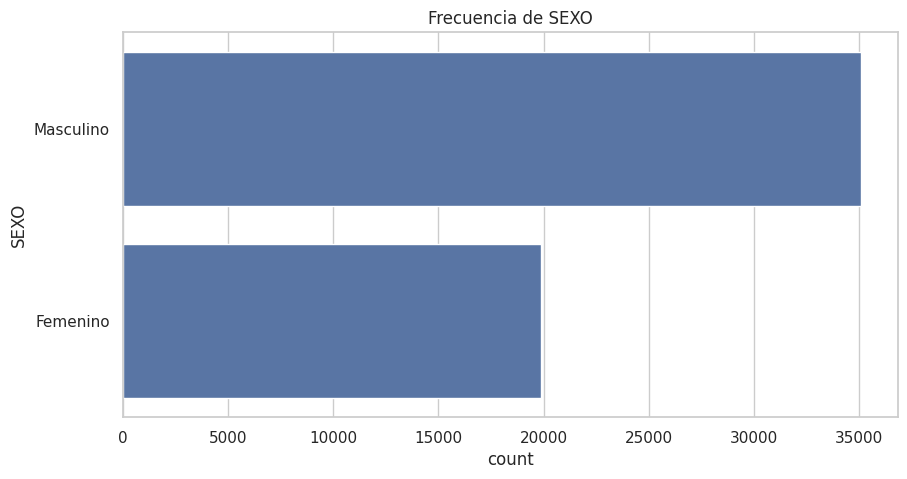

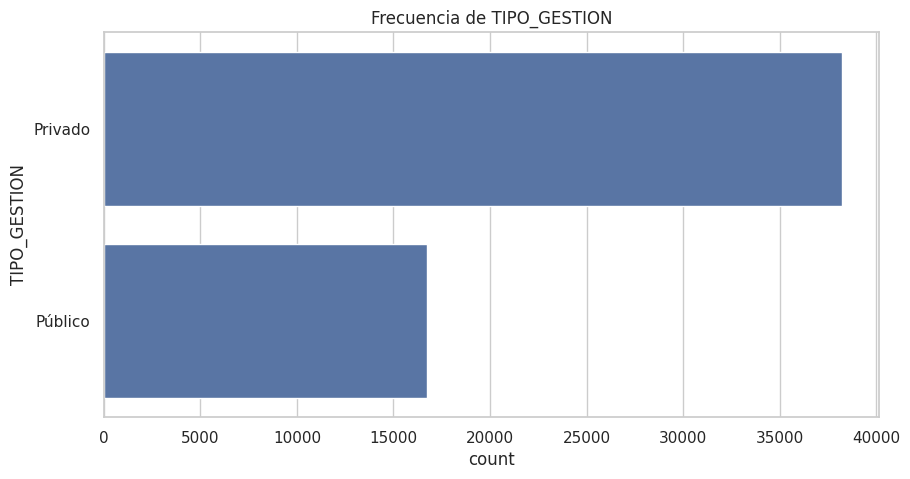

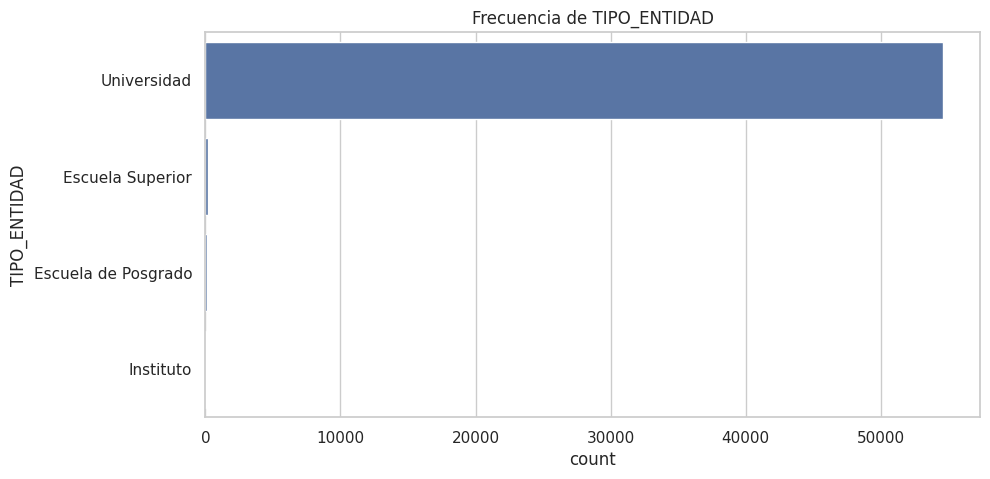

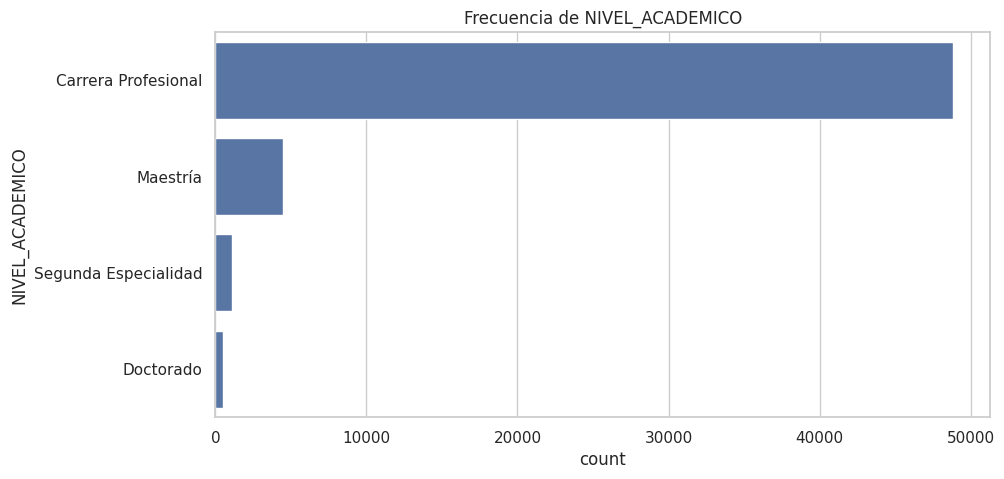

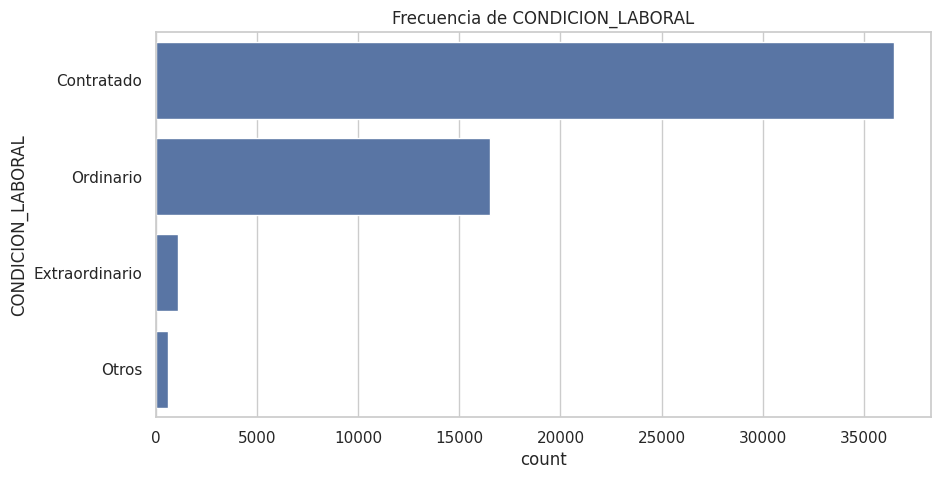

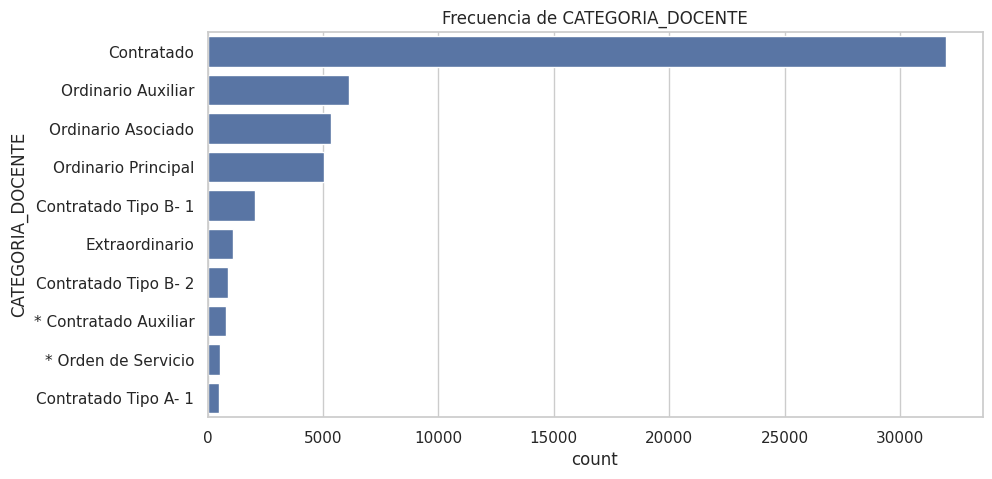

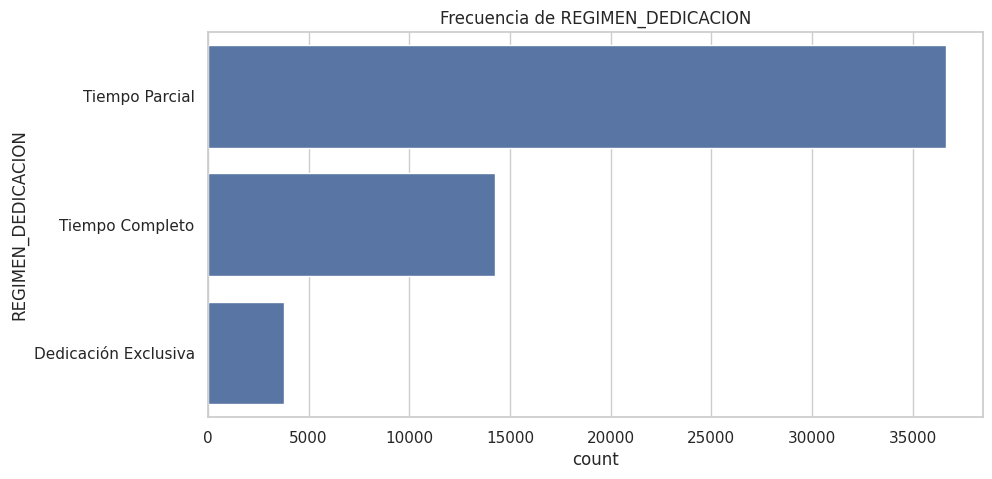

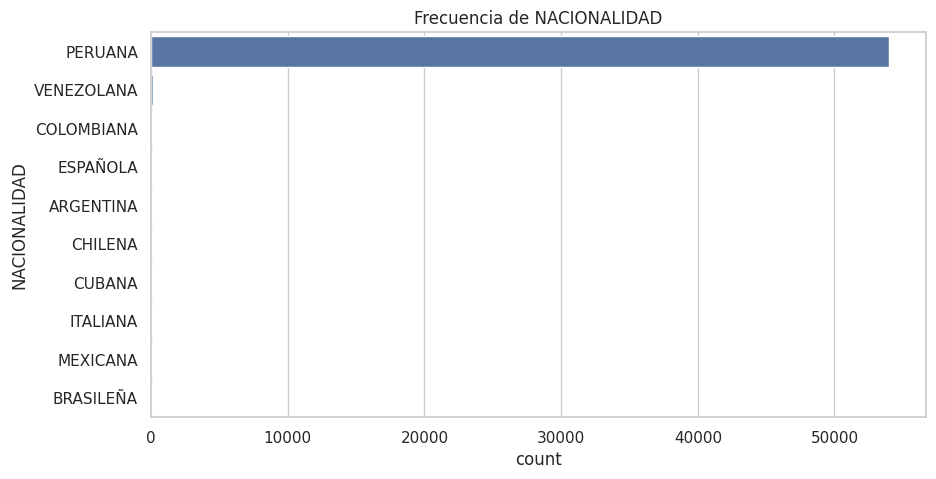

In [16]:
variables_cat_principales = [
    'SEXO',
    'TIPO_GESTION',
    'TIPO_ENTIDAD',
    'NIVEL_ACADEMICO',
    'CONDICION_LABORAL',
    'CATEGORIA_DOCENTE',
    'REGIMEN_DEDICACION',
    'NACIONALIDAD'
]

for col in variables_cat_principales:
    plt.figure(figsize=(10, 5))
    orden = df[col].value_counts().index[:10]
    sns.countplot(data=df, y=col, order=orden)
    plt.title(f'Frecuencia de {col}')
    plt.show()

In [17]:
resumen_categoricas = pd.DataFrame({
    'variable': categoricas,
    'n_unicos': [df[col].nunique() for col in categoricas],
    'moda': [df[col].mode().iloc[0] if not df[col].mode().empty else np.nan for col in categoricas],
    'freq_moda': [df[col].value_counts().iloc[0] if not df[col].value_counts().empty else np.nan for col in categoricas]
})

resumen_categoricas

,variable,n_unicos,moda,freq_moda
0,ENTIDAD,99,Universidad Tecnológica del Perú S.A.C.,7129
1,LICENCIA,3,Licenciada,54489
2,TIPO_GESTION,2,Privado,38227
3,TIPO_ENTIDAD,4,Universidad,54645
4,TIPO_CONSTITUCION,3,Societaria- Con fines de lucro,20626
5,GRUPO_INVESTIGADOR,2,Maria Rostworowski,1236
6,NIVEL_INVESTIGADOR,4,I,647
7,PERIODO_LECTIVO,6,Semestral,53773
8,NIVEL_ACADEMICO,4,Carrera Profesional,48865
9,GUID_PERSONA,47297,{D7D42724-E4FB-4880-8CD1-99FC46EEF5AF},7


In [18]:
tabla_sexo_nivel = pd.crosstab(df['SEXO'], df['NIVEL_ACADEMICO'])
tabla_sexo_nivel

NIVEL_ACADEMICO,Carrera Profesional,Doctorado,Maestría,Segunda Especialidad
SEXO,,,,
Femenino,17885,151,1378,443
Masculino,30980,339,3127,647


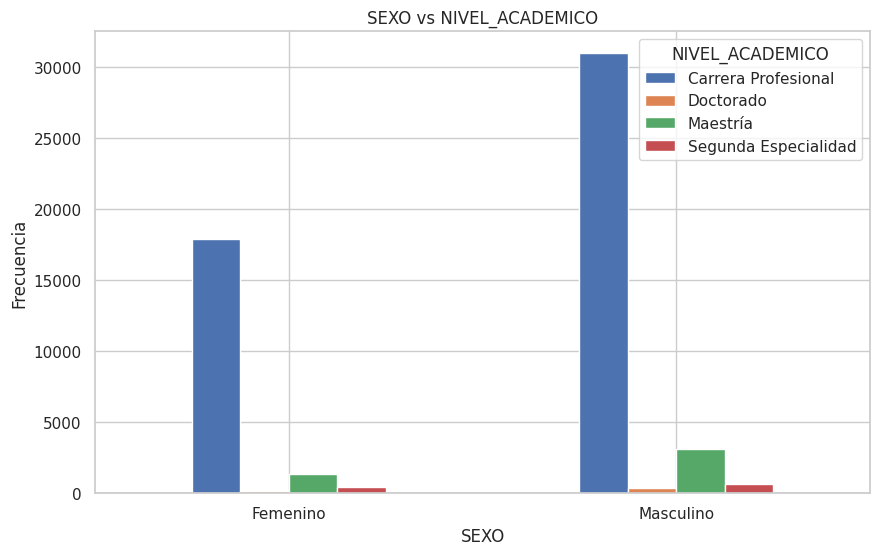

In [19]:
tabla_sexo_nivel.plot(kind='bar', figsize=(10, 6))
plt.title('SEXO vs NIVEL_ACADEMICO')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

In [20]:
tabla_gestion_regimen = pd.crosstab(df['TIPO_GESTION'], df['REGIMEN_DEDICACION'])
tabla_gestion_regimen

REGIMEN_DEDICACION,Dedicación Exclusiva,Tiempo Completo,Tiempo Parcial
TIPO_GESTION,,,
Privado,118,8555,29554
Público,3668,5682,7099


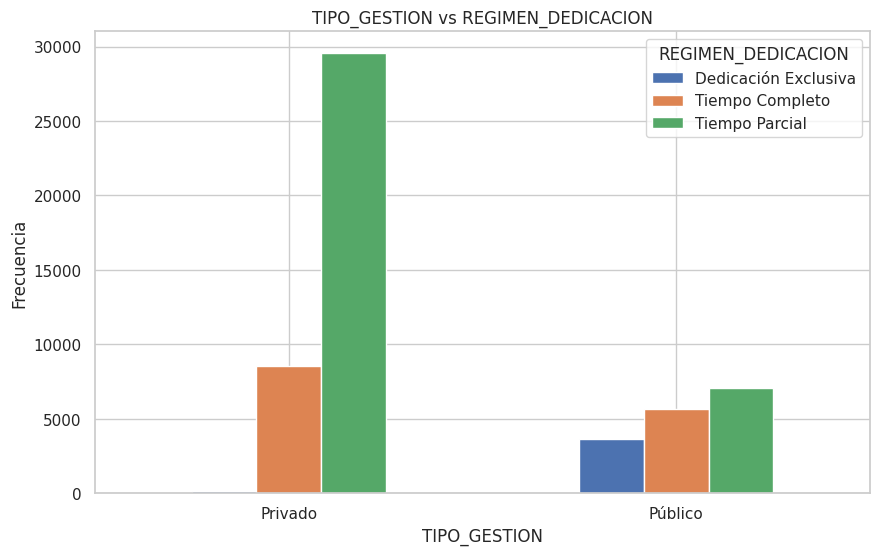

In [21]:
tabla_gestion_regimen.plot(kind='bar', figsize=(10, 6))
plt.title('TIPO_GESTION vs REGIMEN_DEDICACION')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

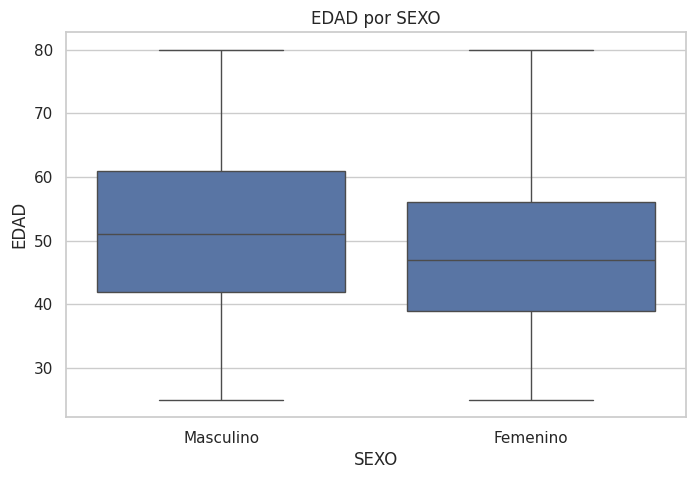

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='SEXO', y='EDAD')
plt.title('EDAD por SEXO')
plt.show()

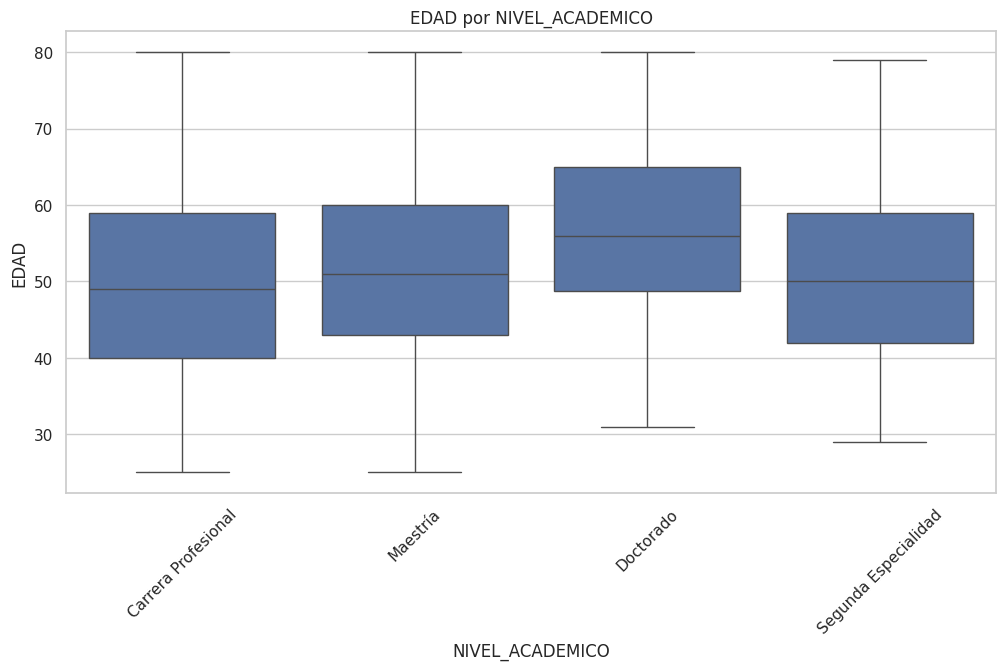

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NIVEL_ACADEMICO', y='EDAD')
plt.xticks(rotation=45)
plt.title('EDAD por NIVEL_ACADEMICO')
plt.show()

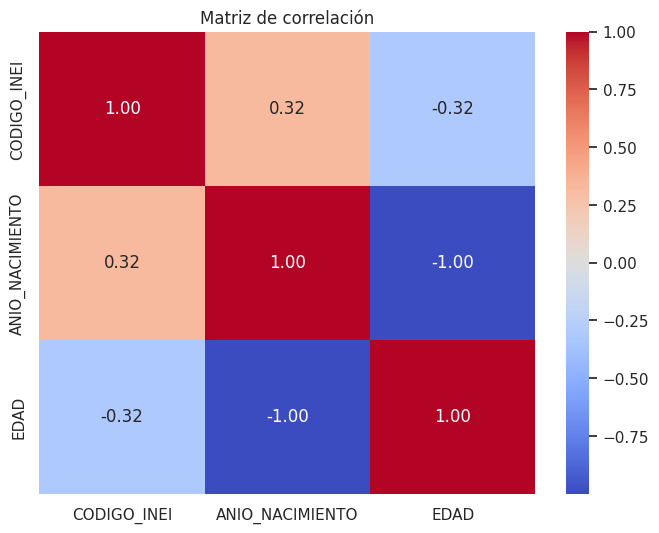

In [24]:
corr = df[numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

In [25]:
cols_categoria = [
    'ENTIDAD', 'LICENCIA', 'TIPO_GESTION', 'TIPO_ENTIDAD', 'TIPO_CONSTITUCION',
    'GRUPO_INVESTIGADOR', 'NIVEL_INVESTIGADOR', 'PERIODO_LECTIVO',
    'NIVEL_ACADEMICO', 'TIPO_GRADO_TITULO', 'PAIS_ENTIDAD', 'SEXO',
    'NACIONALIDAD', 'DEPARTAMENTO_NACIMIENTO', 'CONDICION_LABORAL',
    'CATEGORIA_DOCENTE', 'REGIMEN_DEDICACION'
]

for col in cols_categoria:
    if col in df.columns:
        df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54950 entries, 0 to 54949
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   CODIGO_INEI                51786 non-null  float64       
 1   ENTIDAD                    54950 non-null  category      
 2   LICENCIA                   54950 non-null  category      
 3   TIPO_GESTION               54950 non-null  category      
 4   TIPO_ENTIDAD               54950 non-null  category      
 5   TIPO_CONSTITUCION          54950 non-null  category      
 6   PERIODO_ACADEMICO          54940 non-null  datetime64[ns]
 7   GRUPO_INVESTIGADOR         1894 non-null   category      
 8   NIVEL_INVESTIGADOR         1894 non-null   category      
 9   FECHA_CALIFICACION_INICIO  1894 non-null   datetime64[ns]
 10  FECHA_CALIFICACION_FIN     1894 non-null   datetime64[ns]
 11  PERIODO_ESTANDAR           54950 non-null  datetime64[ns]
 12  PERI

In [26]:
print("===== RESUMEN GENERAL =====")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de variables: {df.shape[1]}")
print(f"Duplicados exactos eliminados: {df.duplicated().sum()}")

print("\n===== VARIABLES NUMÉRICAS =====")
print(df[numericas].describe().T)

print("\n===== PRINCIPALES VARIABLES CATEGÓRICAS =====")
for col in ['SEXO', 'TIPO_GESTION', 'NIVEL_ACADEMICO', 'CONDICION_LABORAL', 'REGIMEN_DEDICACION']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))

===== RESUMEN GENERAL =====
Total de registros: 54950
Total de variables: 29
Duplicados exactos eliminados: 0

===== VARIABLES NUMÉRICAS =====
                   count          mean           std          min  \
CODIGO_INEI      51786.0  2.279817e+08  4.665513e+07  160000001.0   
ANIO_NACIMIENTO  54694.0  1.974162e+03  1.214305e+01       1944.0   
EDAD             54694.0  5.042520e+01  1.213862e+01         25.0   

                         25%          50%          75%          max  
CODIGO_INEI      160000028.0  260000019.0  260000064.0  260000843.0  
ANIO_NACIMIENTO       1965.0       1975.0       1984.0       2000.0  
EDAD                    41.0         49.0         60.0         80.0  

===== PRINCIPALES VARIABLES CATEGÓRICAS =====

--- SEXO ---
SEXO
Masculino    35093
Femenino     19857
Name: count, dtype: int64

--- TIPO_GESTION ---
TIPO_GESTION
Privado    38227
Público    16723
Name: count, dtype: int64

--- NIVEL_ACADEMICO ---
NIVEL_ACADEMICO
Carrera Profesional     48865
Maes

In [27]:
with pd.ExcelWriter('/content/resultados_eda_docentes.xlsx', engine='openpyxl') as writer:
    tabla_nulos.to_excel(writer, sheet_name='nulos')
    df[numericas].describe().T.to_excel(writer, sheet_name='descriptivo_numericas')
    resumen_categoricas.to_excel(writer, sheet_name='resumen_categoricas', index=False)
    tabla_sexo_nivel.to_excel(writer, sheet_name='sexo_vs_nivel')
    tabla_gestion_regimen.to_excel(writer, sheet_name='gestion_vs_regimen')

print("Archivo guardado: /content/resultados_eda_docentes.xlsx")

Archivo guardado: /content/resultados_eda_docentes.xlsx


Shape: (54950, 29)

Tipos de datos:
CODIGO_INEI                         float64
ENTIDAD                              object
LICENCIA                             object
TIPO_GESTION                         object
TIPO_ENTIDAD                         object
TIPO_CONSTITUCION                    object
PERIODO_ACADEMICO            datetime64[ns]
GRUPO_INVESTIGADOR                   object
NIVEL_INVESTIGADOR                   object
FECHA_CALIFICACION_INICIO    datetime64[ns]
FECHA_CALIFICACION_FIN       datetime64[ns]
PERIODO_ESTANDAR             datetime64[ns]
PERIODO_LECTIVO                      object
NIVEL_ACADEMICO                      object
GUID_PERSONA                         object
TIPO_GRADO_TITULO                    object
DENOMINACION_ENTIDAD                 object
FECHA_EXPEDICION_DIPLOMA     datetime64[ns]
PAIS_ENTIDAD                         object
ANIO_NACIMIENTO                     float64
EDAD                                float64
SEXO                                 obj

,nulos,porcentaje_%
NIVEL_INVESTIGADOR,53056,96.55
FECHA_CALIFICACION_INICIO,53056,96.55
FECHA_CALIFICACION_FIN,53056,96.55
GRUPO_INVESTIGADOR,53056,96.55
CODIGO_INEI,3164,5.76
DEPARTAMENTO_NACIMIENTO,1327,2.41
FECHA_EXPEDICION_DIPLOMA,944,1.72
DENOMINACION_ENTIDAD,543,0.99
PAIS_ENTIDAD,543,0.99
TIPO_GRADO_TITULO,541,0.98



Descriptivo numéricas:


,count,mean,std,min,25%,50%,75%,max
CODIGO_INEI,51786.0,2.279817e+08,4.665513e+07,160000001.0,160000028.0,260000019.0,260000064.0,260000843.0
ANIO_NACIMIENTO,54694.0,1.974162e+03,1.214305e+01,1944.0,1965.0,1975.0,1984.0,2000.0
EDAD,54694.0,5.042520e+01,1.213862e+01,25.0,41.0,49.0,60.0,80.0


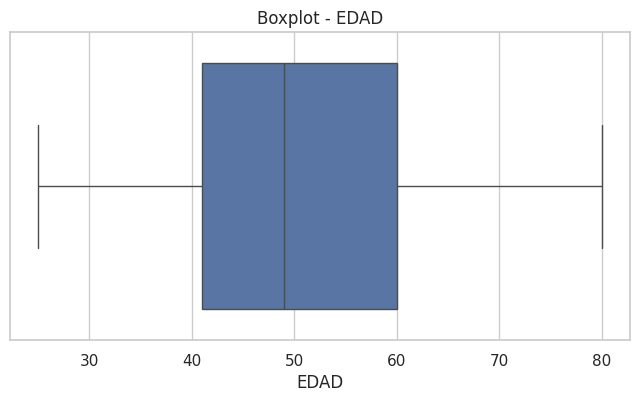

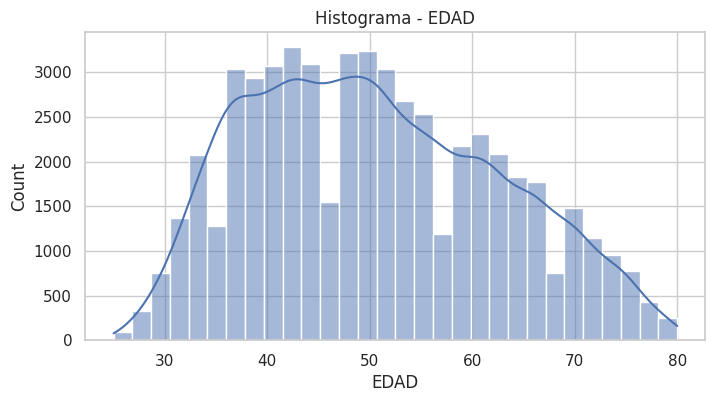

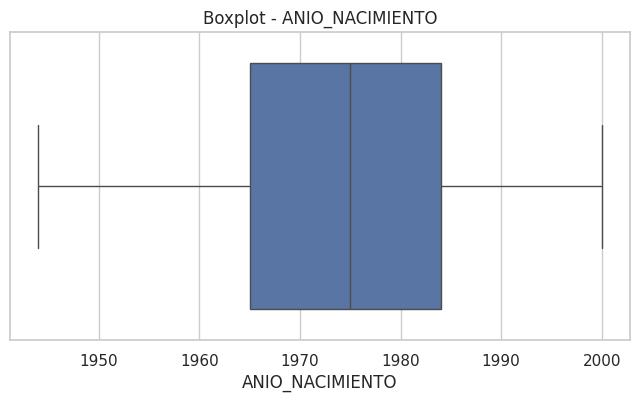

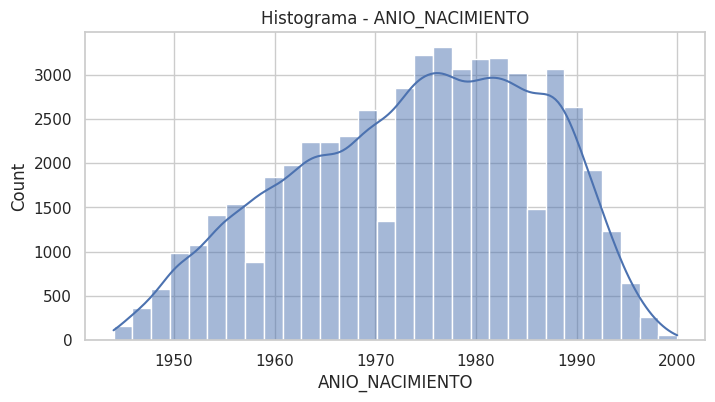

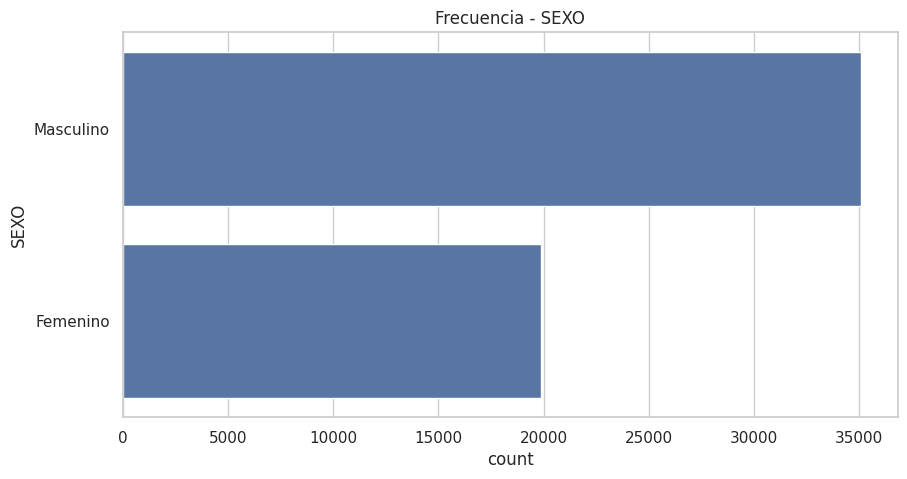

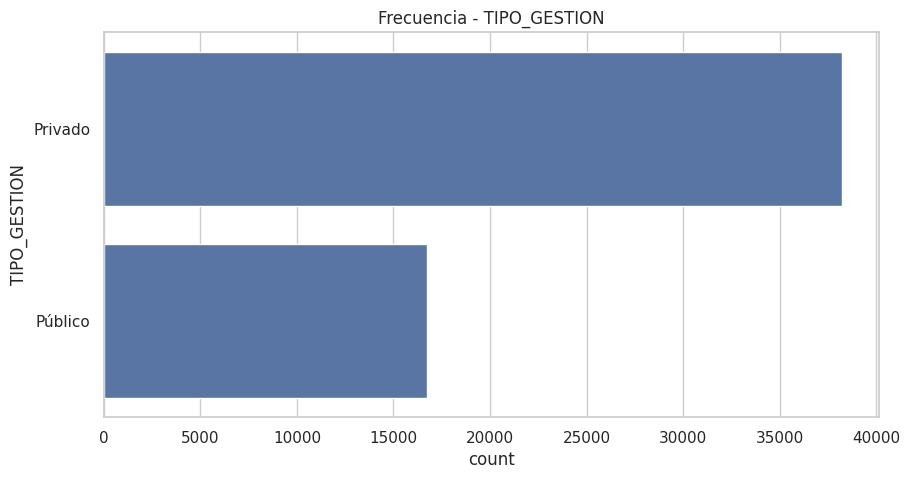

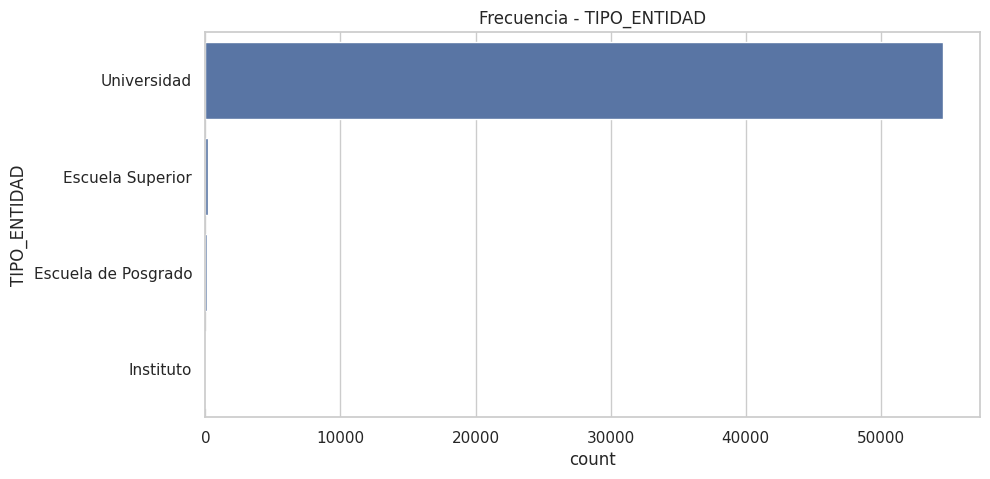

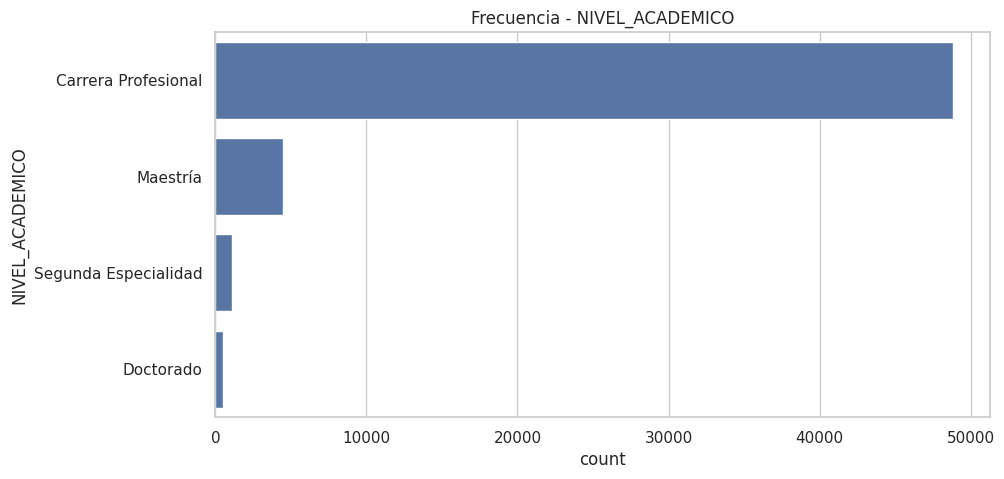

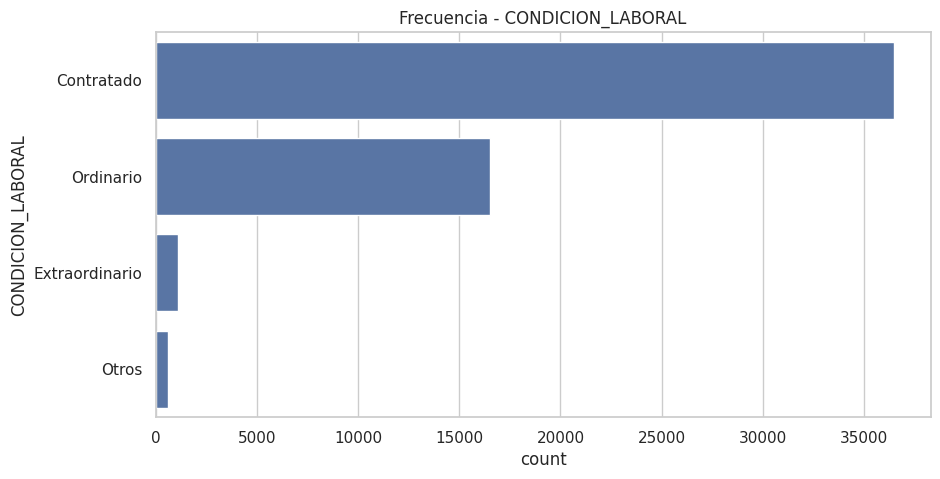

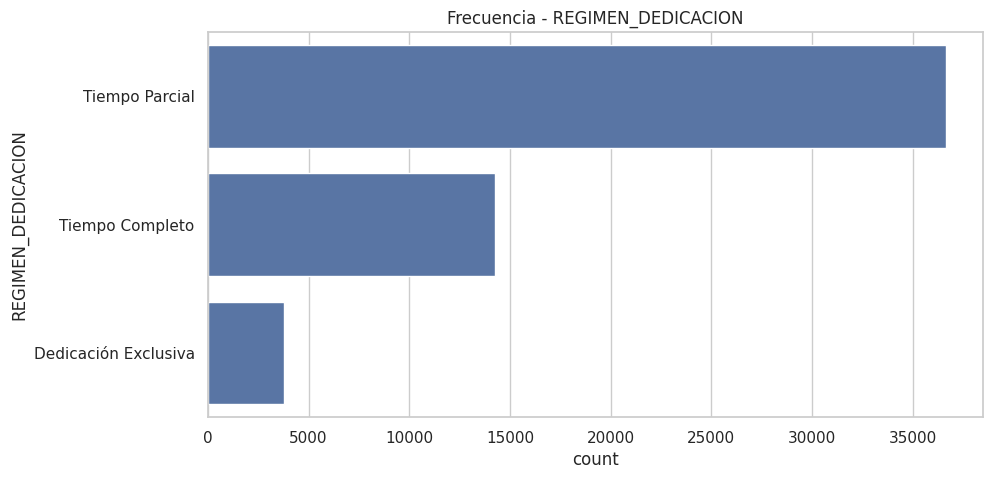

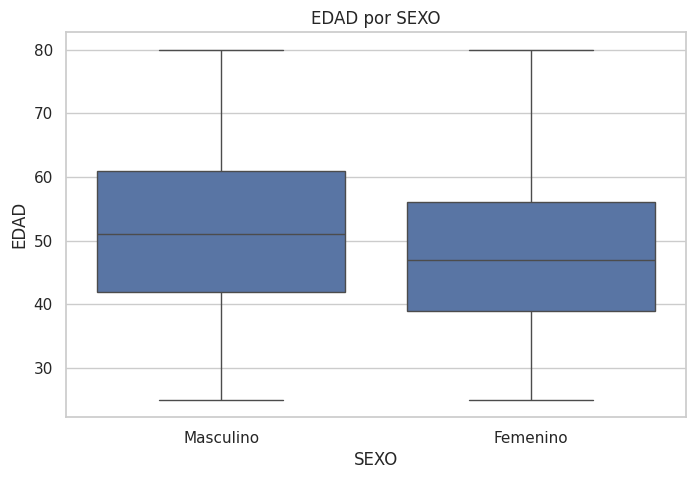

NIVEL_ACADEMICO,Carrera Profesional,Doctorado,Maestría,Segunda Especialidad
SEXO,,,,
Femenino,17885,151,1378,443
Masculino,30980,339,3127,647


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

archivo = '/content/datadocentes2_hnupaddpq7.xlsx'
df = pd.read_excel(archivo, sheet_name='docente_2025_I')

df.columns = df.columns.str.strip()
df = df.drop_duplicates()

numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nNulos:")
display(pd.DataFrame({
    'nulos': df.isnull().sum(),
    'porcentaje_%': (df.isnull().sum()/len(df)*100).round(2)
}).sort_values('porcentaje_%', ascending=False))

print("\nDescriptivo numéricas:")
display(df[numericas].describe().T)

for col in ['EDAD', 'ANIO_NACIMIENTO']:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot - {col}')
        plt.show()

        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'Histograma - {col}')
        plt.show()

for col in ['SEXO', 'TIPO_GESTION', 'TIPO_ENTIDAD', 'NIVEL_ACADEMICO', 'CONDICION_LABORAL', 'REGIMEN_DEDICACION']:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        orden = df[col].value_counts().index[:10]
        sns.countplot(data=df, y=col, order=orden)
        plt.title(f'Frecuencia - {col}')
        plt.show()

if 'SEXO' in df.columns and 'EDAD' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='SEXO', y='EDAD')
    plt.title('EDAD por SEXO')
    plt.show()

if 'SEXO' in df.columns and 'NIVEL_ACADEMICO' in df.columns:
    display(pd.crosstab(df['SEXO'], df['NIVEL_ACADEMICO']))

ENERGIA ELECTRCIA CLUSTERING

In [29]:
!pip -q install openpyxl scikit-learn pandas matplotlib seaborn

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [44]:
import pandas as pd

archivo = "/content/dataenergíaeléctrica_kjvgcdvrjj.xlsx"

df = pd.read_excel(
    archivo,
    usecols=["IMPORTE S/", "CONSUMO kWh"],
    nrows=50000,
    engine="openpyxl"
)

df.head()

,IMPORTE S/,CONSUMO kWh
0,14.2,18
1,8.0,5
2,13.7,14
3,7.3,0
4,311.8,298


In [45]:
df.columns = ["IMPORTE", "CONSUMO"]

df["IMPORTE"] = pd.to_numeric(df["IMPORTE"], errors="coerce")
df["CONSUMO"] = pd.to_numeric(df["CONSUMO"], errors="coerce")

df = df.dropna()
df = df[(df["IMPORTE"] >= 0) & (df["CONSUMO"] >= 0)]

print(df.shape)

(50000, 2)


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

X = df[["IMPORTE", "CONSUMO"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=5000, n_init=10)
df["CLUSTER"] = kmeans.fit_predict(X_scaled)

print(df["CLUSTER"].value_counts())

CLUSTER
0    26513
2    12342
1     9641
3     1504
Name: count, dtype: int64


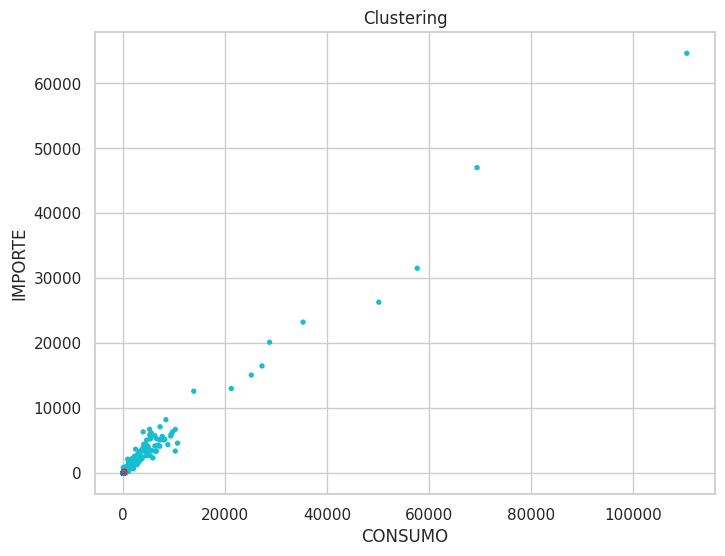

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(df["CONSUMO"], df["IMPORTE"], c=df["CLUSTER"], s=8, cmap="tab10")
plt.xlabel("CONSUMO")
plt.ylabel("IMPORTE")
plt.title("Clustering")
plt.show()

In [48]:
usecols=["IMPORTE S/", "CONSUMO kWh"]